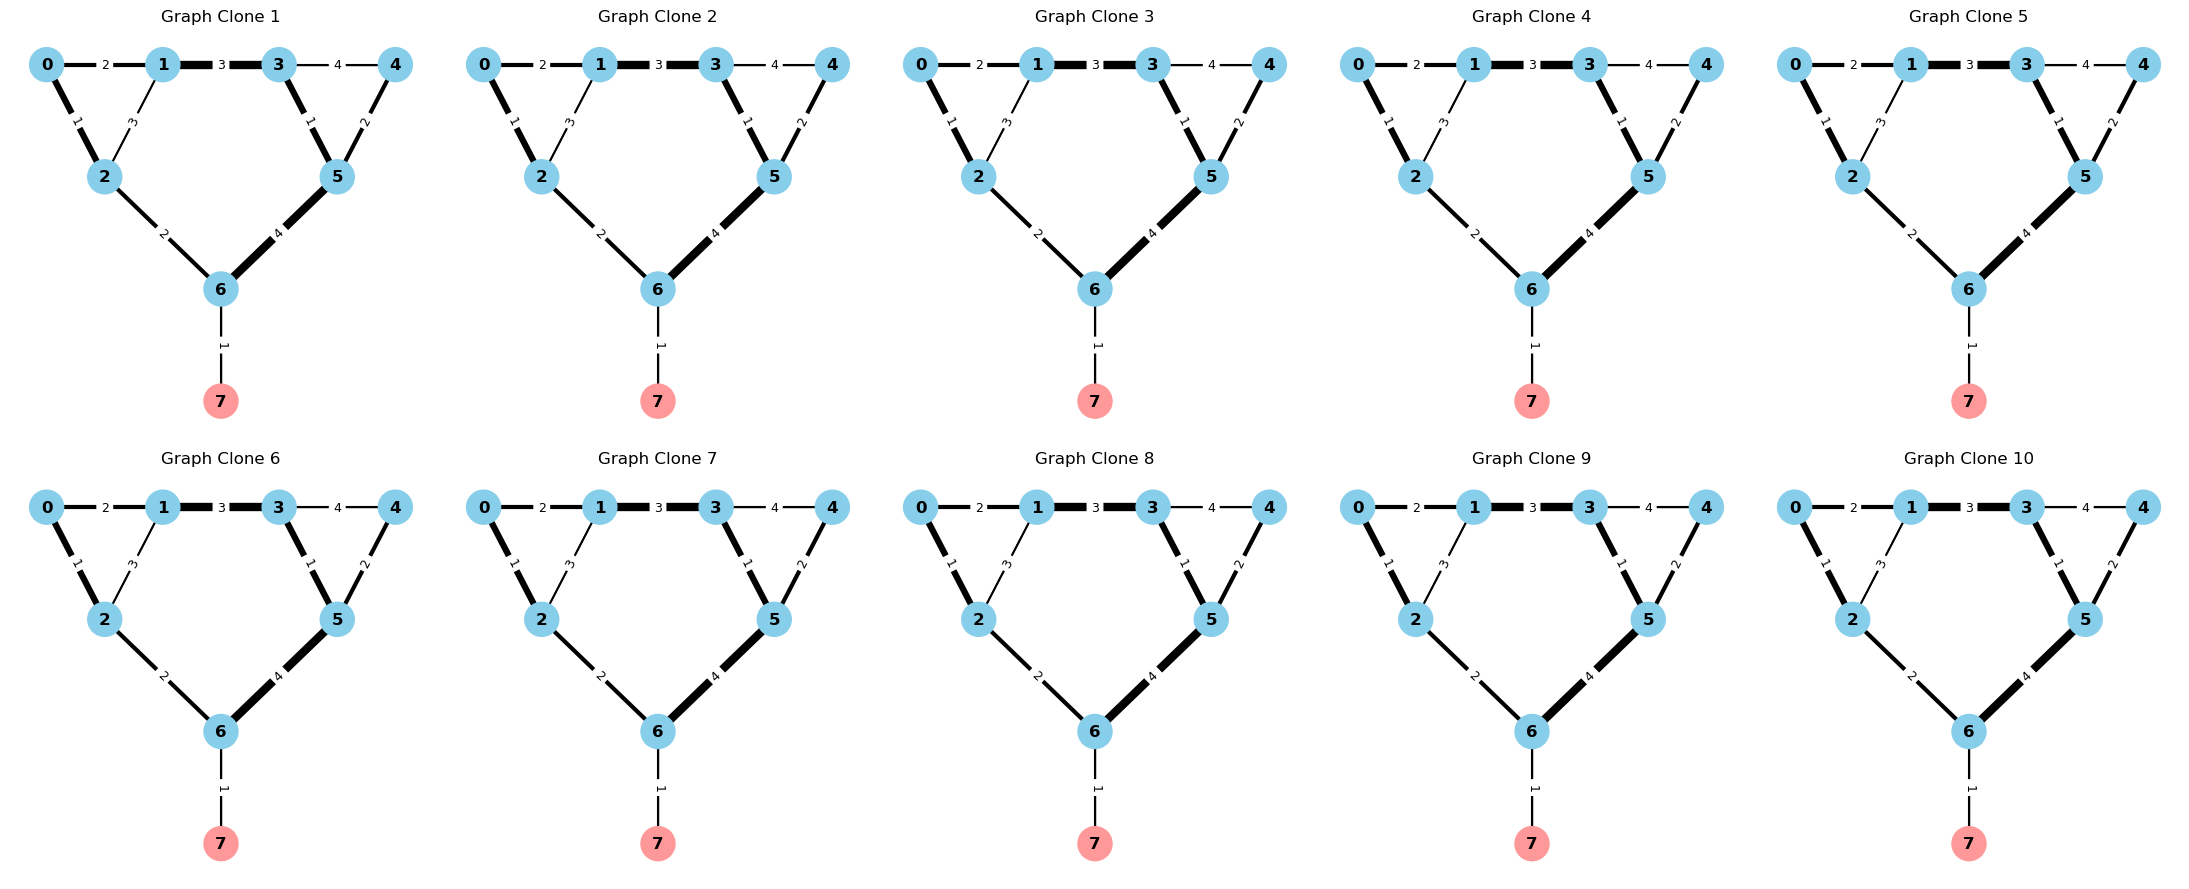

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the fixed nodes and edges
nodes = [0, 1, 2, 3, 4, 5, 6, 7]
edges = [
    (0, 1), (1, 2), (2, 0),  # Left Block
    (3, 4), (4, 5), (5, 3),  # Right Block
    (1, 3),                  # Top connector
    (2, 6), (5, 6),          # Funnel to intersection
    (6, 7)                   # Cul-de-sac
]

# 2. ONE single set of weights for ALL 10 graphs (values 1-4)
fixed_weights = [2, 3, 1, 4, 2, 1, 3, 2, 4, 1]

# 3. Generate 10 exact clones
graphs = []
for _ in range(10):
    G = nx.Graph()
    G.add_nodes_from(nodes)
    for i, (u, v) in enumerate(edges):
        G.add_edge(u, v, weight=fixed_weights[i])
    graphs.append(G)

# 4. Plotting the 10 identical graphs
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

# Fixed coordinates for map layout
pos = {
    0: (0, 1),    1: (1, 1),    2: (0.5, 0),  # Left Block
    3: (2, 1),    4: (3, 1),    5: (2.5, 0),  # Right Block
    6: (1.5, -1),                             # Intersection
    7: (1.5, -2)                              # Cul-de-sac
}

for i, G in enumerate(graphs):
    # Highlight the cul-de-sac (Node 7) in red, others in blue
    node_colors = ['#ff9999' if G.degree(n) == 1 else 'skyblue' for n in G.nodes()]
    
    # Draw graph elements
    nx.draw(G, pos, ax=axes[i], with_labels=True, 
            node_color=node_colors, node_size=600, font_weight='bold')
    
    # Draw edges: thicker lines for heavier traffic
    nx.draw_networkx_edges(G, pos, ax=axes[i], width=[w * 1.5 for w in fixed_weights])
    
    # Add explicit weight labels to the edges
    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes[i], font_size=9)
    
    axes[i].set_title(f"Graph Clone {i+1}")

plt.tight_layout()
plt.show()

In [9]:
import itertools
import networkx as nx

# 1. Select one of our identical graphs
G = graphs[0]

# 2. Generate all unique pairs of nodes (Order doesn't matter, so A->B is the same as B->A)
# For 8 nodes, this will be (8 * 7) / 2 = 28 unique pairs
unique_pairs = list(itertools.combinations(G.nodes(), 2))
total_pairs = len(unique_pairs)

# 3. Calculate shortest path lengths for all pairs based on edge 'weight'
all_path_lengths = dict(nx.shortest_path_length(G, weight='weight'))

# 4. Filter and count paths with a total weight <= 2
fast_paths = []
for u, v in unique_pairs:
    path_weight = all_path_lengths[u][v]
    if path_weight <= 2:
        fast_paths.append((u, v, path_weight))

count_fast_paths = len(fast_paths)

# 5. Calculate the percentage
percentage = (count_fast_paths / total_pairs) * 100

# 6. Print the results clearly
print(f"Total possible unique routes: {total_pairs}")
print(f"Routes with a weight of 2 or less: {count_fast_paths}")
print(f"Percentage of fast routes: {percentage:.2f}%\n")

print("Here are the specific fast routes:")
for u, v, weight in fast_paths:
    print(f" - Node {u} to Node {v} (Weight: {weight})")

Total possible unique routes: 28
Routes with a weight of 2 or less: 6
Percentage of fast routes: 21.43%

Here are the specific fast routes:
 - Node 0 to Node 1 (Weight: 2)
 - Node 0 to Node 2 (Weight: 1)
 - Node 2 to Node 6 (Weight: 2)
 - Node 3 to Node 5 (Weight: 1)
 - Node 4 to Node 5 (Weight: 2)
 - Node 6 to Node 7 (Weight: 1)


In [ ]:
import itertools
import networkx as nx
import random

# 1. Select one of our identical graphs (using a copy so we don't alter the original)
G = graphs[0].copy()

# 2. Add a random 'demand' value (e.g., between 10 and 100) to every edge
random.seed(42) # For reproducible results
for u, v in G.edges():
    G.edges[u, v]['demand'] = random.randint(1, 10)

# 3. Generate all unique pairs of nodes
unique_pairs = list(itertools.combinations(G.nodes(), 2))
total_pairs = len(unique_pairs)

# 4. Calculate shortest path lengths AND get the actual sequence of nodes
all_path_lengths = dict(nx.shortest_path_length(G, weight='weight'))
all_paths = dict(nx.shortest_path(G, weight='weight'))

# 5. Filter for fast paths and calculate the demand along those routes
fast_paths = []
for u, v in unique_pairs:
    path_weight = all_path_lengths[u][v]
    
    if path_weight <= 2:
        # Get the actual node-by-node route (e.g., [0, 1, 3])
        node_sequence = all_paths[u][v]
        
        # Add up the 'demand' for every edge along this specific route
        route_demand = 0
        for i in range(len(node_sequence) - 1):
            node_a = node_sequence[i]
            node_b = node_sequence[i+1]
            route_demand += G.edges[node_a, node_b]['demand']
            
        fast_paths.append((u, v, path_weight, route_demand, node_sequence))

count_fast_paths = len(fast_paths)

# 6. Calculate the percentage
percentage = (count_fast_paths / total_pairs) * 100

# 7. Print the results clearly
print(f"Total possible unique routes: {total_pairs}")
print(f"Routes with a weight (length) of 2 or less: {count_fast_paths}")
print(f"Percentage of fast routes: {percentage:.2f}%\n")

print("Here are the specific fast routes with their traffic demand:")
print(f"{'Route':<15} | {'Path Taken':<15} | {'Length':<8} | {'Total Demand'}")
print("-" * 60)
for u, v, weight, demand, path in fast_paths:
    print(f"Node {u} to {v:<6} | {str(path):<15} | {weight:<8} | {demand}")

Total possible unique routes: 28
Routes with a weight (length) of 2 or less: 6
Percentage of fast routes: 21.43%

Here are the specific fast routes with their traffic demand:
Route           | Path Taken      | Length   | Total Demand
------------------------------------------------------------
Node 0 to 1      | [0, 1]          | 2        | 91
Node 0 to 2      | [0, 2]          | 1        | 24
Node 2 to 6      | [2, 6]          | 2        | 41
Node 3 to 5      | [3, 5]          | 1        | 27
Node 4 to 5      | [4, 5]          | 2        | 23
Node 6 to 7      | [6, 7]          | 1        | 79


<class 'networkx.utils.decorators.argmap'> compilation 50:3: FutureWarning: 

shortest_path will return an iterator that yields
(node, path) pairs instead of a dictionary when source
and target are unspecified beginning in version 3.5

To keep the current behavior, use:

	dict(nx.shortest_path(G))


In [13]:
import networkx as nx
import random

# 1. Define the base structure and starting weights
nodes = [0, 1, 2, 3, 4, 5, 6, 7]
edges = [
    (0, 1), (1, 2), (2, 0), (3, 4), (4, 5), 
    (5, 3), (1, 3), (2, 6), (5, 6), (6, 7)
]
initial_weights = [2, 3, 1, 4, 2, 1, 3, 2, 4, 1]

# Create the baseline graph (Graph 1)
G_base = nx.Graph()
G_base.add_nodes_from(nodes)
for i, (u, v) in enumerate(edges):
    G_base.add_edge(u, v, weight=initial_weights[i])


# --- METHOD 1: RANDOM SELECTION ---
graphs_random = [G_base.copy()]
random.seed(42) # For reproducibility

for _ in range(9): # Generate Graphs 2 through 10
    G_next = graphs_random[-1].copy()
    
    # Find all edges that aren't already 1
    upgradeable_edges = [(u, v) for u, v, d in G_next.edges(data=True) if d['weight'] > 1]
    
    if upgradeable_edges:
        # Pick one at random and set to 1
        edge_to_upgrade = random.choice(upgradeable_edges)
        G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
        
    graphs_random.append(G_next)


# --- METHOD 2: EDGE BETWEENNESS CENTRALITY ---
graphs_centrality = [G_base.copy()]

for _ in range(9): # Generate Graphs 2 through 10
    G_next = graphs_centrality[-1].copy()
    
    # Calculate betweenness centrality using weight as distance
    # Higher weight = longer distance, which NetworkX handles natively
    centrality = nx.edge_betweenness_centrality(G_next, weight='weight')
    
    # Filter for edges that can still be upgraded (weight > 1)
    upgradeable_centrality = {
        edge: cent for edge, cent in centrality.items() 
        if G_next[edge[0]][edge[1]]['weight'] > 1
    }
    
    if upgradeable_centrality:
        # Find the edge with the highest centrality score
        edge_to_upgrade = max(upgradeable_centrality, key=upgradeable_centrality.get)
        G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
        
    graphs_centrality.append(G_next)

import itertools
import networkx as nx

# 1. Wrap your analysis logic into a reusable function
def calculate_fast_routes_percentage(G, max_weight=2):
    unique_pairs = list(itertools.combinations(G.nodes(), 2))
    total_pairs = len(unique_pairs)
    
    # Calculate shortest path lengths for all pairs
    all_path_lengths = dict(nx.shortest_path_length(G, weight='weight'))
    
    # Count paths with a total weight <= max_weight
    count_fast_paths = 0
    for u, v in unique_pairs:
        if all_path_lengths[u][v] <= max_weight:
            count_fast_paths += 1
            
    # Return the percentage
    return (count_fast_paths / total_pairs) * 100

# 2. Store the results for both methods
random_percentages = []
centrality_percentages = []

# 3. Loop through all 10 stages for both graph lists
for i in range(10):
    pct_random = calculate_fast_routes_percentage(graphs_random[i])
    pct_centrality = calculate_fast_routes_percentage(graphs_centrality[i])
    
    random_percentages.append(pct_random)
    centrality_percentages.append(pct_centrality)

# 4. Print the results side-by-side
print("Percentage of routes completable with a weight of 2 or less:\n")
print(f"{'Graph Stage':<15} | {'Random Strategy':<20} | {'Centrality Strategy'}")
print("-" * 60)
for i in range(10):
    print(f"Graph {i+1:<9} | {random_percentages[i]:>18.2f}% | {centrality_percentages[i]:>18.2f}%")

Percentage of routes completable with a weight of 2 or less:

Graph Stage     | Random Strategy      | Centrality Strategy
------------------------------------------------------------
Graph 1         |              21.43% |              21.43%
Graph 2         |              25.00% |              28.57%
Graph 3         |              28.57% |              42.86%
Graph 4         |              28.57% |              50.00%
Graph 5         |              28.57% |              57.14%
Graph 6         |              46.43% |              64.29%
Graph 7         |              57.14% |              71.43%
Graph 8         |              75.00% |              75.00%
Graph 9         |              75.00% |              75.00%
Graph 10        |              75.00% |              75.00%


In [14]:
import itertools
import networkx as nx
import random

# 1. Define the base structure and starting weights
nodes = [0, 1, 2, 3, 4, 5, 6, 7]
edges = [
    (0, 1), (1, 2), (2, 0), (3, 4), (4, 5), 
    (5, 3), (1, 3), (2, 6), (5, 6), (6, 7)
]
initial_weights = [2, 3, 1, 4, 2, 1, 3, 2, 4, 1]

# Create the baseline graph (Graph 1)
G_base = nx.Graph()
G_base.add_nodes_from(nodes)
for i, (u, v) in enumerate(edges):
    G_base.add_edge(u, v, weight=initial_weights[i])

# --- NEW: Generate a fixed Origin-Destination Demand Matrix ---
# We assign a random demand (10-100) to every unique pair of nodes. 
# This stays constant across all graphs so the test is fair.
random.seed(123)
unique_pairs = list(itertools.combinations(nodes, 2))
od_demand = {pair: random.randint(10, 100) for pair in unique_pairs}
total_network_demand = sum(od_demand.values())


# --- METHOD 1: RANDOM SELECTION ---
graphs_random = [G_base.copy()]
random.seed(42) # For reproducibility

for _ in range(9): # Generate Graphs 2 through 10
    G_next = graphs_random[-1].copy()
    upgradeable_edges = [(u, v) for u, v, d in G_next.edges(data=True) if d['weight'] > 1]
    
    if upgradeable_edges:
        edge_to_upgrade = random.choice(upgradeable_edges)
        G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
        
    graphs_random.append(G_next)


# --- METHOD 2: EDGE BETWEENNESS CENTRALITY ---
graphs_centrality = [G_base.copy()]

for _ in range(9): # Generate Graphs 2 through 10
    G_next = graphs_centrality[-1].copy()
    centrality = nx.edge_betweenness_centrality(G_next, weight='weight')
    
    upgradeable_centrality = {
        edge: cent for edge, cent in centrality.items() 
        if G_next[edge[0]][edge[1]]['weight'] > 1
    }
    
    if upgradeable_centrality:
        edge_to_upgrade = max(upgradeable_centrality, key=upgradeable_centrality.get)
        G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
        
    graphs_centrality.append(G_next)


# --- UPDATED ANALYSIS: Demand Satisfied ---
def calculate_satisfied_demand_percentage(G, demand_matrix, total_demand, max_weight=2):
    # Calculate shortest path lengths for all pairs
    all_path_lengths = dict(nx.shortest_path_length(G, weight='weight'))
    
    satisfied_demand = 0
    
    # Loop through every pair and check if they can travel in <= max_weight
    for u, v in demand_matrix.keys():
        if all_path_lengths[u][v] <= max_weight:
            # If the route is fast enough, add this pair's specific demand to our success pile
            satisfied_demand += demand_matrix[(u, v)]
            
    # Return the percentage of the TOTAL demand that is satisfied
    return (satisfied_demand / total_demand) * 100


# 2. Store the results for both methods
random_demand_pct = []
centrality_demand_pct = []

# 3. Loop through all 10 stages
for i in range(10):
    pct_random = calculate_satisfied_demand_percentage(graphs_random[i], od_demand, total_network_demand)
    pct_centrality = calculate_satisfied_demand_percentage(graphs_centrality[i], od_demand, total_network_demand)
    
    random_demand_pct.append(pct_random)
    centrality_demand_pct.append(pct_centrality)

# 4. Print the results side-by-side
print(f"Total Network Demand (All Pairs): {total_network_demand}\n")
print("Percentage of Total Demand Satisfied (Distance <= 2):\n")
print(f"{'Graph Stage':<15} | {'Random Strategy':<20} | {'Centrality Strategy'}")
print("-" * 60)
for i in range(10):
    print(f"Graph {i+1:<9} | {random_demand_pct[i]:>18.2f}% | {centrality_demand_pct[i]:>18.2f}%")

Total Network Demand (All Pairs): 1243

Percentage of Total Demand Satisfied (Distance <= 2):

Graph Stage     | Random Strategy      | Centrality Strategy
------------------------------------------------------------
Graph 1         |              20.68% |              20.68%
Graph 2         |              28.64% |              26.71%
Graph 3         |              33.31% |              39.50%
Graph 4         |              33.31% |              49.16%
Graph 5         |              33.31% |              59.61%
Graph 6         |              54.38% |              65.97%
Graph 7         |              64.68% |              72.65%
Graph 8         |              79.16% |              79.16%
Graph 9         |              79.16% |              79.16%
Graph 10        |              79.16% |              79.16%


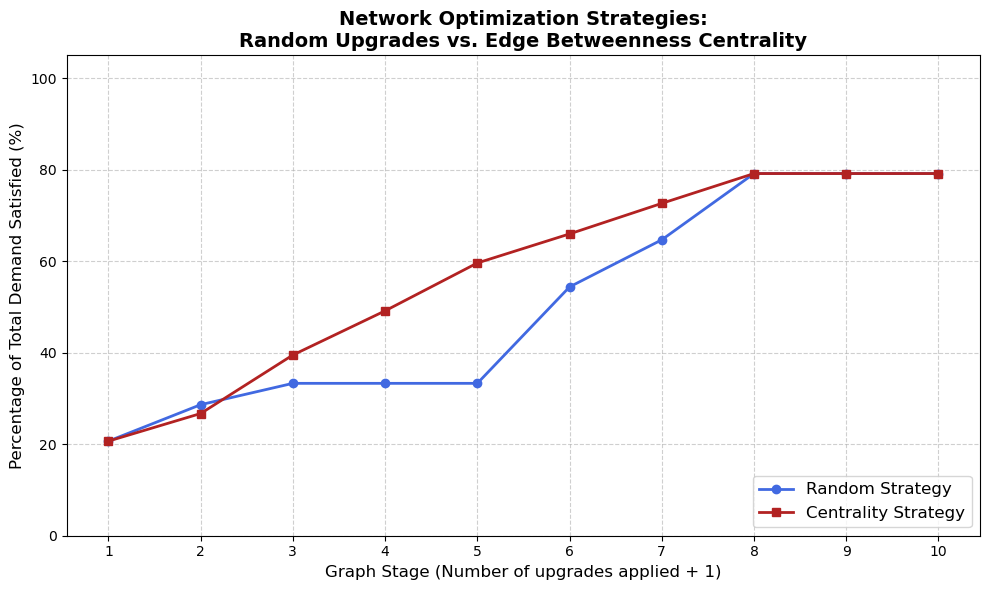

In [15]:
import matplotlib.pyplot as plt

# 1. Define the x-axis (Graph stages 1 through 10)
stages = list(range(1, 11))

# 2. Set up the plot
plt.figure(figsize=(10, 6))

# 3. Plot both strategies
plt.plot(stages, random_demand_pct, marker='o', linestyle='-', color='royalblue', linewidth=2, label='Random Strategy')
plt.plot(stages, centrality_demand_pct, marker='s', linestyle='-', color='firebrick', linewidth=2, label='Centrality Strategy')

# 4. Add titles and labels
plt.title('Network Optimization Strategies:\nRandom Upgrades vs. Edge Betweenness Centrality', fontsize=14, fontweight='bold')
plt.xlabel('Graph Stage (Number of upgrades applied + 1)', fontsize=12)
plt.ylabel('Percentage of Total Demand Satisfied (%)', fontsize=12)

# 5. Format the axes and layout
plt.xticks(stages)
plt.ylim(0, 105) # Limit Y axis from 0 to slightly above 100% for readability
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='lower right')

# 6. Display the chart
plt.tight_layout()
plt.show()

<class 'networkx.utils.decorators.argmap'> compilation 25:3: FutureWarning: 

shortest_path will return an iterator that yields
(node, path) pairs instead of a dictionary when source
and target are unspecified beginning in version 3.5

To keep the current behavior, use:

	dict(nx.shortest_path(G))


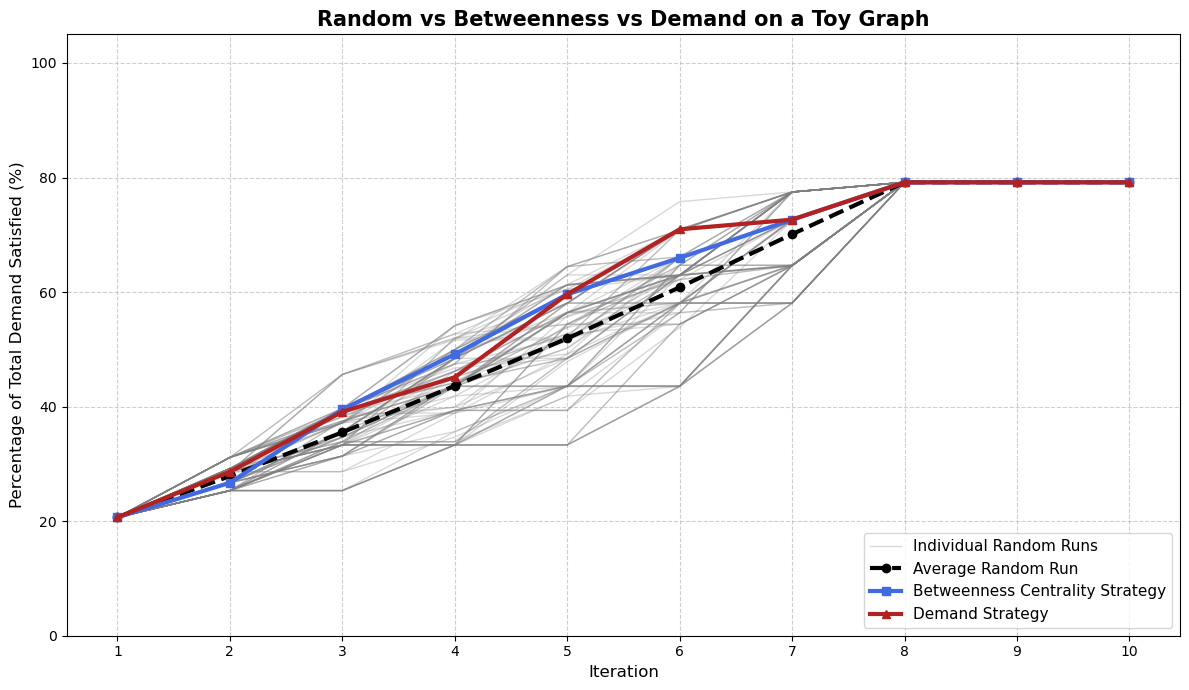

In [1]:
import itertools
import networkx as nx
import random
import matplotlib.pyplot as plt

# 1. Define the base structure and starting weights
nodes = [0, 1, 2, 3, 4, 5, 6, 7]
edges = [
    (0, 1), (1, 2), (2, 0), (3, 4), (4, 5), 
    (5, 3), (1, 3), (2, 6), (5, 6), (6, 7)
]
initial_weights = [2, 3, 1, 4, 2, 1, 3, 2, 4, 1]

# Create the baseline graph
G_base = nx.Graph()
G_base.add_nodes_from(nodes)
for i, (u, v) in enumerate(edges):
    G_base.add_edge(u, v, weight=initial_weights[i])

# Generate a fixed Origin-Destination Demand Matrix
random.seed(123)
unique_pairs = list(itertools.combinations(nodes, 2))
od_demand = {pair: random.randint(10, 100) for pair in unique_pairs}
total_network_demand = sum(od_demand.values())

# Analysis Function
def calculate_satisfied_demand_percentage(G, demand_matrix, total_demand, max_weight=2):
    all_path_lengths = dict(nx.shortest_path_length(G, weight='weight'))
    satisfied_demand = sum(
        demand_matrix[(u, v)] for u, v in demand_matrix.keys() 
        if all_path_lengths[u][v] <= max_weight
    )
    return (satisfied_demand / total_demand) * 100

# --- METHOD 1: MULTIPLE RANDOM RUNS ---
num_random_runs = 100
all_random_pcts = []

for run in range(num_random_runs):
    # We don't need a fixed seed here because we WANT different random paths
    current_random_graphs = [G_base.copy()]
    
    for _ in range(9): 
        G_next = current_random_graphs[-1].copy()
        upgradeable_edges = [(u, v) for u, v, d in G_next.edges(data=True) if d['weight'] > 1]
        if upgradeable_edges:
            edge_to_upgrade = random.choice(upgradeable_edges)
            G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
        current_random_graphs.append(G_next)
        
    # Calculate percentages for this specific random run
    run_pcts = [calculate_satisfied_demand_percentage(g, od_demand, total_network_demand) for g in current_random_graphs]
    all_random_pcts.append(run_pcts)

# Calculate the mean of the random runs for each stage
mean_random_pcts = [sum(stage_values)/num_random_runs for stage_values in zip(*all_random_pcts)]


# --- METHOD 2: EDGE BETWEENNESS CENTRALITY ---
graphs_centrality = [G_base.copy()]
for _ in range(9):
    G_next = graphs_centrality[-1].copy()
    centrality = nx.edge_betweenness_centrality(G_next, weight='weight')
    upgradeable_centrality = {e: c for e, c in centrality.items() if G_next[e[0]][e[1]]['weight'] > 1}
    
    if upgradeable_centrality:
        edge_to_upgrade = max(upgradeable_centrality, key=upgradeable_centrality.get)
        G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
    graphs_centrality.append(G_next)

centrality_pcts = [calculate_satisfied_demand_percentage(g, od_demand, total_network_demand) for g in graphs_centrality]


# --- METHOD 3: ACTUAL EDGE DEMAND (LOAD) ---
graphs_demand = [G_base.copy()]
for _ in range(9):
    G_next = graphs_demand[-1].copy()
    
    # 1. Calculate how much demand is routed over each physical edge
    edge_loads = {edge: 0 for edge in G_next.edges()}
    all_paths = dict(nx.shortest_path(G_next, weight='weight'))
    
    for (u, v), demand in od_demand.items():
        path = all_paths[u][v]
        for i in range(len(path) - 1):
            n1, n2 = path[i], path[i+1]
            # Match edge regardless of direction (u->v or v->u)
            if (n1, n2) in edge_loads:
                edge_loads[(n1, n2)] += demand
            else:
                edge_loads[(n2, n1)] += demand
                
    # 2. Filter for edges we can still upgrade
    upgradeable_loads = {e: load for e, load in edge_loads.items() if G_next[e[0]][e[1]]['weight'] > 1}
    
    # 3. Upgrade the edge carrying the highest total demand
    if upgradeable_loads:
        edge_to_upgrade = max(upgradeable_loads, key=upgradeable_loads.get)
        G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
        
    graphs_demand.append(G_next)

demand_pcts = [calculate_satisfied_demand_percentage(g, od_demand, total_network_demand) for g in graphs_demand]


# --- PLOTTING ---
stages = list(range(1, 11))
plt.figure(figsize=(12, 7))

# Plot all 10 individual random runs (faint lines)
for i, run_pcts in enumerate(all_random_pcts):
    # Only label the first one so the legend doesn't get cluttered
    label = 'Individual Random Runs' if i == 0 else ""
    plt.plot(stages, run_pcts, color='gray', alpha=0.3, linewidth=1, label=label)

# Plot the Mean of the Random Runs
plt.plot(stages, mean_random_pcts, marker='o', linestyle='--', color='black', linewidth=3, label='Average Random Run')

# Plot Centrality Strategy
plt.plot(stages, centrality_pcts, marker='s', linestyle='-', color='royalblue', linewidth=3, label='Betweenness Centrality Strategy')

# Plot Demand Strategy
plt.plot(stages, demand_pcts, marker='^', linestyle='-', color='firebrick', linewidth=3, label='Demand Strategy')

plt.title('Random vs Betweenness vs Demand on a Toy Graph', fontsize=15, fontweight='bold')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Percentage of Total Demand Satisfied (%)', fontsize=12)
plt.xticks(stages)
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

Running Random runs... (This might take a few seconds)
Running Centrality strategy...
Running Demand strategy...


<class 'networkx.utils.decorators.argmap'> compilation 45:3: FutureWarning: 

shortest_path will return an iterator that yields
(node, path) pairs instead of a dictionary when source
and target are unspecified beginning in version 3.5

To keep the current behavior, use:

	dict(nx.shortest_path(G))


Generating Plot...


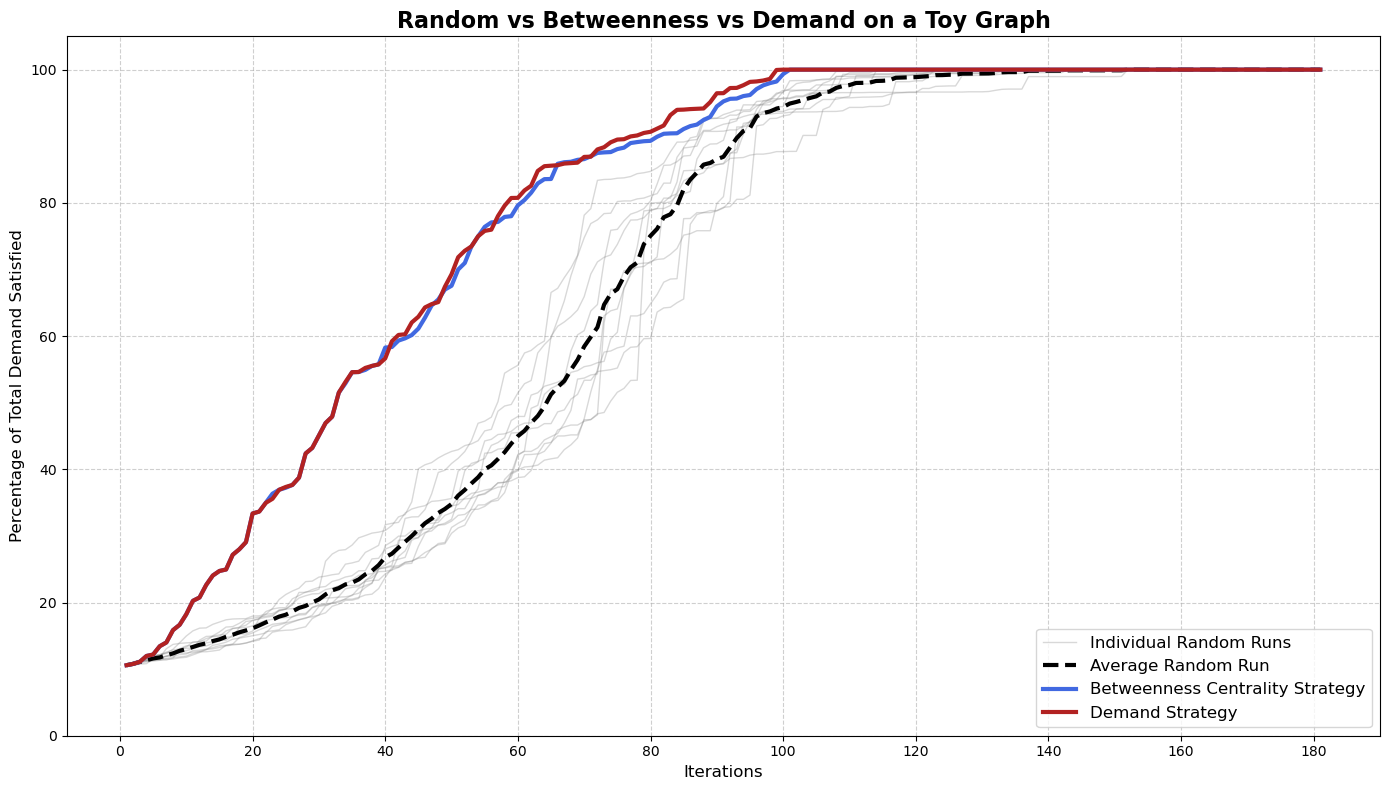

In [1]:
import itertools
import networkx as nx
import random
import matplotlib.pyplot as plt

# 1. Create a 100-node Grid Graph (10x10 city blocks)
base_grid = nx.grid_2d_graph(10, 10)

# Relabel nodes from coordinates (e.g., (0,0)) to simple integers (0 to 99)
mapping = {node: i for i, node in enumerate(base_grid.nodes())}
G_base = nx.relabel_nodes(base_grid, mapping)

# Assign random initial weights between 2 and 25 
random.seed(42)
for u, v in G_base.edges():
    G_base[u][v]['weight'] = random.randint(2, 25)

# Generate a fixed Origin-Destination Demand Matrix
random.seed(123)
unique_pairs = list(itertools.combinations(G_base.nodes(), 2))
od_demand = {pair: random.randint(10, 100) for pair in unique_pairs}
total_network_demand = sum(od_demand.values())

# Analysis Function
def calculate_satisfied_demand_percentage(G, demand_matrix, total_demand, max_weight=26):
    all_path_lengths = dict(nx.shortest_path_length(G, weight='weight'))
    satisfied_demand = sum(
        demand_matrix[(u, v)] for u, v in demand_matrix.keys() 
        if all_path_lengths[u][v] <= max_weight
    )
    return (satisfied_demand / total_demand) * 100

# --- METHOD 1: MULTIPLE RANDOM RUNS ---
num_random_runs = 10 
all_random_pcts = []

print("Running Random runs... (This might take a few seconds)")
for run in range(num_random_runs):
    current_random_graphs = [G_base.copy()]
    
    # Run 180 times to upgrade every single edge
    for _ in range(180): 
        G_next = current_random_graphs[-1].copy()
        upgradeable_edges = [(u, v) for u, v, d in G_next.edges(data=True) if d['weight'] > 1]
        if upgradeable_edges:
            edge_to_upgrade = random.choice(upgradeable_edges)
            G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
        current_random_graphs.append(G_next)
        
    run_pcts = [calculate_satisfied_demand_percentage(g, od_demand, total_network_demand) for g in current_random_graphs]
    all_random_pcts.append(run_pcts)

mean_random_pcts = [sum(stage_values)/num_random_runs for stage_values in zip(*all_random_pcts)]

# --- METHOD 2: EDGE BETWEENNESS CENTRALITY ---
print("Running Centrality strategy...")
graphs_centrality = [G_base.copy()]
for _ in range(180):
    G_next = graphs_centrality[-1].copy()
    centrality = nx.edge_betweenness_centrality(G_next, weight='weight')
    upgradeable_centrality = {e: c for e, c in centrality.items() if G_next[e[0]][e[1]]['weight'] > 1}
    
    if upgradeable_centrality:
        edge_to_upgrade = max(upgradeable_centrality, key=upgradeable_centrality.get)
        G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
    graphs_centrality.append(G_next)

centrality_pcts = [calculate_satisfied_demand_percentage(g, od_demand, total_network_demand) for g in graphs_centrality]

# --- METHOD 3: ACTUAL EDGE DEMAND (LOAD) ---
print("Running Demand strategy...")
graphs_demand = [G_base.copy()]
for _ in range(180):
    G_next = graphs_demand[-1].copy()
    
    edge_loads = {edge: 0 for edge in G_next.edges()}
    all_paths = dict(nx.shortest_path(G_next, weight='weight'))
    
    for (u, v), demand in od_demand.items():
        path = all_paths[u][v]
        for i in range(len(path) - 1):
            n1, n2 = path[i], path[i+1]
            if (n1, n2) in edge_loads:
                edge_loads[(n1, n2)] += demand
            else:
                edge_loads[(n2, n1)] += demand
                
    upgradeable_loads = {e: load for e, load in edge_loads.items() if G_next[e[0]][e[1]]['weight'] > 1}
    
    if upgradeable_loads:
        edge_to_upgrade = max(upgradeable_loads, key=upgradeable_loads.get)
        G_next[edge_to_upgrade[0]][edge_to_upgrade[1]]['weight'] = 1
        
    graphs_demand.append(G_next)

demand_pcts = [calculate_satisfied_demand_percentage(g, od_demand, total_network_demand) for g in graphs_demand]

# --- PLOTTING ---
print("Generating Plot...")
# 1 base graph + 180 upgrades = 181 total stages
stages = list(range(1, 182))
plt.figure(figsize=(14, 8))

for i, run_pcts in enumerate(all_random_pcts):
    label = 'Individual Random Runs' if i == 0 else ""
    plt.plot(stages, run_pcts, color='gray', alpha=0.3, linewidth=1, label=label)

plt.plot(stages, mean_random_pcts, marker='', linestyle='--', color='black', linewidth=3, label='Average Random Run')
plt.plot(stages, centrality_pcts, marker='', linestyle='-', color='royalblue', linewidth=3, label='Betweenness Centrality Strategy')
plt.plot(stages, demand_pcts, marker='', linestyle='-', color='firebrick', linewidth=3, label='Demand Strategy')

plt.title('Random vs Betweenness vs Demand on a Toy Graph', fontsize=16, fontweight='bold')
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Percentage of Total Demand Satisfied', fontsize=12)
plt.xticks(range(0, 185, 20)) # Spread the ticks out nicely to 180
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.show()

------------------

# Simple example on Newcastle

In [65]:
import osmnx as ox
import networkx as nx
import itertools
import random
import numpy as np
import matplotlib.pyplot as plt


G_ncl = ox.graph_from_place("Newcastle upon Tyne, UK", network_type="bike")
G_ncl_undir = G_ncl.to_undirected()


lts_lookup = {
    "motorway": 4,
    "motorway_link": 4,
    "trunk": 4,
    "trunk_link": 4,
    "primary": 4,
    "primary_link": 4,
    "secondary": 4,
    "secondary_link": 4,
    "tertiary": 3,
    "tertiary_link": 3,
    "unclassified": 3,
    "service": 3,
    "residential": 2,
    "living_street": 2,
    "cycleway": 1,
    "track": 1,
    "path": 1,
    "bridleway": 1,
    "footway": 1,
    "pedestrian": 1 # only if bicycle = yes
    }

for u, v, k, data in G_ncl_undir.edges(keys=True, data=True):

    highway = data.get("highway")
    length = data.get("length", 0.0)

    if isinstance(highway, list):
        # take the *lowest stress* class if multiple are tagged
        lts_class = min(lts_lookup.get(h, 4) for h in highway)
    elif isinstance(highway, str):
        lts_class = lts_lookup.get(highway, 4)
    else:
        lts_class = 3  # if unknown, assume moderate stress

    data["lts_class"] = lts_class
    data["lts_distance"] = float(length) * float(lts_class)

for u, v, data in list(G_ncl_undir.edges(data=True))[:10]:
    print(u, v, data)


6565642 13800629 {'osmid': 2953792, 'oneway': True, 'lanes': '3', 'ref': 'A1', 'highway': 'trunk', 'maxspeed': '60 mph', 'reversed': False, 'length': 612.471, 'geometry': <LINESTRING (-1.684 54.992, -1.687 54.991, -1.689 54.989, -1.69 54.988)>, 'lts_class': 4, 'lts_distance': 2449.884}
6565642 13800665 {'osmid': 194663137, 'oneway': True, 'lanes': '2', 'ref': 'A1', 'highway': 'trunk', 'maxspeed': '60 mph', 'reversed': False, 'length': 816.466, 'geometry': <LINESTRING (-1.677 54.998, -1.68 54.996, -1.682 54.994, -1.684 54.992)>, 'lts_class': 4, 'lts_distance': 3265.864}
6565642 13801142 {'osmid': 4662063, 'oneway': True, 'highway': 'trunk_link', 'maxspeed': '60 mph', 'reversed': False, 'length': 386.474, 'geometry': <LINESTRING (-1.681 54.995, -1.681 54.995, -1.681 54.995, -1.682 54.994, -1....>, 'lts_class': 4, 'lts_distance': 1545.896}
6565645 13800665 {'osmid': [921085898, 194663139], 'oneway': True, 'lanes': '3', 'ref': 'A1', 'highway': 'trunk', 'maxspeed': '60 mph', 'reversed': Fal

# Triangulation

In [66]:
# make a tiny triangulation with known nodes

target_osmids = {9143323824, 30123988, 2017374170, 289173842, 251426204}


tri_nodes = {nid: G_ncl_undir.nodes[nid] for nid in target_osmids }

for nid, data in tri_nodes.items():
    print(nid, data)




9143323824 {'y': 54.9868205, 'x': -1.6260433, 'street_count': 4}
289173842 {'y': 54.991237, 'x': -1.5861865, 'street_count': 3}
30123988 {'y': 54.9974786, 'x': -1.6053354, 'street_count': 4}
2017374170 {'y': 54.9875531, 'x': -1.6071056, 'street_count': 4}
251426204 {'y': 55.0033191, 'x': -1.5875976, 'street_count': 1}


<Axes: >

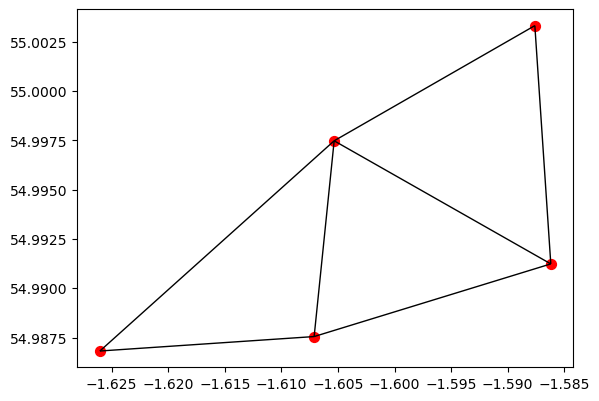

In [67]:
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import LineString
from scipy.spatial import Delaunay
import numpy as np

rows = []
for nid, data in tri_nodes.items():
    rows.append({
        "osmid": nid,
        "x": data["x"],
        "y": data["y"],
        "geometry": Point(data["x"], data["y"])
    })

nodes_gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")



coords = nodes_gdf[["x", "y"]].values
tri = Delaunay(coords)


edges = set()

for simplex in tri.simplices:
    pairs = [(simplex[0], simplex[1]),
             (simplex[1], simplex[2]),
             (simplex[2], simplex[0])]

    for i, j in pairs:
        edge = tuple(sorted((i, j)))
        edges.add(edge)




edge_rows = []

for i, j in edges:
    p1 = nodes_gdf.iloc[i]
    p2 = nodes_gdf.iloc[j]

    edge_rows.append({
        "u": p1["osmid"],
        "v": p2["osmid"],
        "geometry": LineString([p1.geometry, p2.geometry])
    })

tri_edges_gdf = gpd.GeoDataFrame(edge_rows, crs="EPSG:4326")
tri_edges_gdf = tri_edges_gdf.to_crs(3857)
tri_edges_gdf["length"] = tri_edges_gdf.geometry.length
tri_edges_gdf.to_crs(4326, inplace=True)

ax = tri_edges_gdf.plot(color="black", linewidth=1)
nodes_gdf.plot(ax=ax, color="red", markersize=50)



## Prep methods

### Betweeness

            u           v  betweenness
0    30123988   251426204          3.0
2  9143323824  2017374170          2.0
4    30123988  2017374170          2.0
5  9143323824    30123988          2.0
6   289173842  2017374170          2.0
1   289173842    30123988          1.0
3   289173842   251426204          1.0


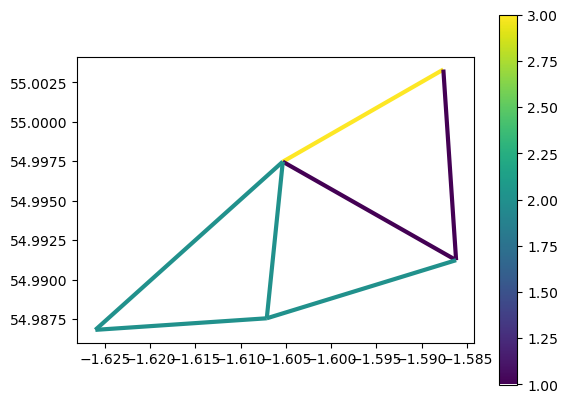

In [68]:
import networkx as nx

G_tri = nx.Graph()

for _, row in tri_edges_gdf.iterrows():
    G_tri.add_edge(
        row["u"],
        row["v"],
        length=row["length"]
    )

ebc = nx.edge_betweenness_centrality(
    G_tri,
    weight="length",
    normalized=False
)

tri_edges_gdf["betweenness"] = tri_edges_gdf.apply(
    lambda r: ebc.get((r["u"], r["v"]), ebc.get((r["v"], r["u"]), 0)),
    axis=1
)

tri_edges_gdf.plot(
    column="betweenness",
    cmap="viridis",
    legend=True,
    linewidth=3
)
betweenness_sorted_edges = tri_edges_gdf.sort_values("betweenness", ascending=False)[["u", "v", "betweenness"]]
print(betweenness_sorted_edges)

### Demand

In [76]:
# add some demand values (made up!)
tri_edges_gdf["demand"] = [5, 4, 16, 36, 2, 3, 10]
demand_sorted_edges = tri_edges_gdf.sort_values("demand", ascending=False)[["u", "v", "demand"]]
print(demand_sorted_edges)

            u           v  demand
3   289173842   251426204      36
2  9143323824  2017374170      16
6   289173842  2017374170      10
0    30123988   251426204       5
1   289173842    30123988       4
5  9143323824    30123988       3
4    30123988  2017374170       2


## Grow network

In [77]:
def get_lts_distance(row):
    try:
        return nx.shortest_path_length(
            G_ncl_undir,
            source=row["u"],
            target=row["v"],
            weight="lts_distance"
        )
    except nx.NetworkXNoPath:
        return None

tri_edges_gdf["lts_shortest"] = tri_edges_gdf.apply(get_lts_distance, axis=1)

total_length = tri_edges_gdf["lts_shortest"].sum()

In [88]:
# create 10 evenly spaced values from 0 to total_length (inclusive)
steps = list(np.linspace(0, total_length, 10))
print(steps)

[0.0, 2717.494666666666, 5434.989333333332, 8152.483999999999, 10869.978666666664, 13587.47333333333, 16304.967999999997, 19022.462666666663, 21739.95733333333, 24457.451999999994]


### Random

In [89]:
random_edge_dfs = [
    tri_edges_gdf.sample(frac=1).reset_index(drop=True)[["u", "v", "demand", "lts_shortest", "length"]]
    for _ in range(10)
]

=== DIAGNOSTIC ===
Already satisfied at baseline:
            u           v  demand       length  lts_shortest  \
0    30123988   251426204       5  2276.795136      4295.025   
1   289173842    30123988       4  2451.716110      4388.328   
2  9143323824  2017374170      16  2112.921368      2644.480   
3   289173842   251426204      36  2349.986111      3577.764   
4    30123988  2017374170       2  1936.032708      2993.438   
5  9143323824    30123988       3  3096.936365      3199.581   
6   289173842  2017374170      10  2435.933510      3358.836   

   already_satisfied  
0              False  
1              False  
2               True  
3              False  
4              False  
5               True  
6               True  

  Edge 30123988-251426204: length=2276.8, lts_shortest=4295.0, current_dist=4295.0, threshold(x1.5)=3415.2, satisfied=NO
  Edge 289173842-30123988: length=2451.7, lts_shortest=4388.3, current_dist=4388.3, threshold(x1.5)=3677.6, satisfied=NO
  Edge 914

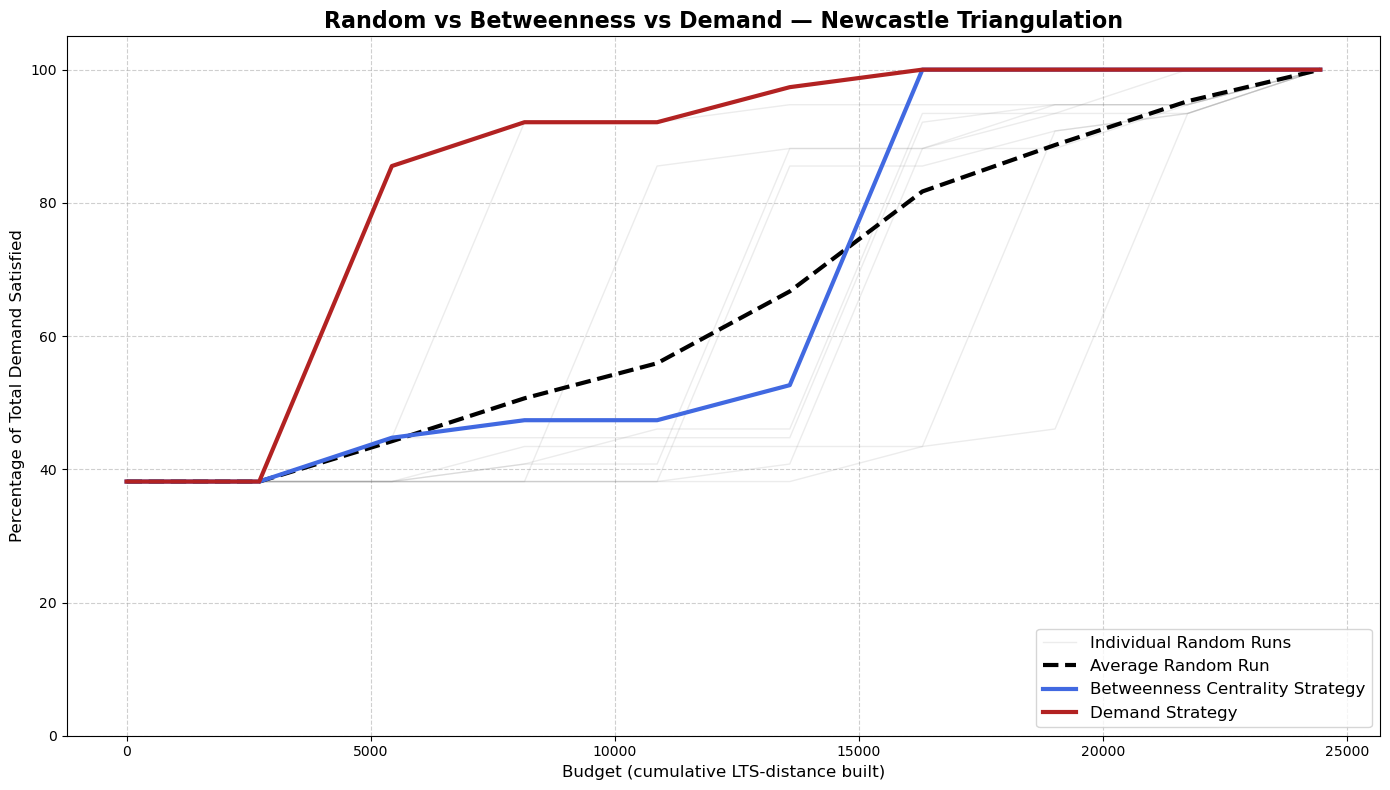

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

def evaluate_network_with_built_edges(G_base, built_edges_df, tri_edges_gdf, demand_col="demand"):
    """
    Mirrors the toy graph approach:
    - Start with the real network
    - For each "built" triangulation edge, add a low-stress shortcut
    - Then measure demand satisfied
    """
    # Convert to simple Graph to avoid multigraph key issues
    G = nx.Graph()
    for u, v, data in G_base.edges(data=True):
        if G.has_edge(u, v):
            if data.get("lts_distance", float("inf")) < G[u][v].get("lts_distance", float("inf")):
                G[u][v].update(data)
        else:
            G.add_edge(u, v, **data)
    
    # Add each built edge as a new low-stress shortcut (LTS 1 → cost = length)
    for _, row in built_edges_df.iterrows():
        u, v = int(row["u"]), int(row["v"])
        new_cost = row["length"]  # physical length, LTS 1
        if G.has_node(u) and G.has_node(v):
            if G.has_edge(u, v):
                if new_cost < G[u][v].get("lts_distance", float("inf")):
                    G[u][v]["lts_distance"] = new_cost
            else:
                G.add_edge(u, v, lts_distance=new_cost)
    
    total_demand = tri_edges_gdf[demand_col].sum()
    satisfied_demand = 0
    
    for _, row in tri_edges_gdf.iterrows():
        u, v = int(row["u"]), int(row["v"])
        
        try:
            new_dist = nx.shortest_path_length(G, u, v, weight="lts_distance")
        except nx.NetworkXNoPath:
            new_dist = float("inf")
        
        threshold = row["length"] * 1.5
        
        if new_dist <= threshold:
            satisfied_demand += row[demand_col]
    
    return (satisfied_demand / total_demand) * 100 if total_demand > 0 else 0


def evaluate_strategy(ordered_edges, steps, G_base, tri_edges_gdf):
    ordered_edges = ordered_edges.copy()
    ordered_edges["cumulative_cost"] = ordered_edges["lts_shortest"].cumsum()
    
    pcts = []
    for budget in steps:
        built = ordered_edges[ordered_edges["cumulative_cost"] <= budget + 1e-6]
        pct = evaluate_network_with_built_edges(G_base, built, tri_edges_gdf)
        pcts.append(pct)
    
    return pcts


# --- Identify which edges are already satisfied at baseline ---
G_simple = nx.Graph()
for u, v, data in G_ncl_undir.edges(data=True):
    if G_simple.has_edge(u, v):
        if data.get("lts_distance", float("inf")) < G_simple[u][v].get("lts_distance", float("inf")):
            G_simple[u][v].update(data)
    else:
        G_simple.add_edge(u, v, **data)

already_satisfied = []
for _, row in tri_edges_gdf.iterrows():
    u, v = int(row["u"]), int(row["v"])
    try:
        current_dist = nx.shortest_path_length(G_simple, u, v, weight="lts_distance")
    except nx.NetworkXNoPath:
        current_dist = float("inf")
    already_satisfied.append(current_dist <= row["length"] * 1.5)

tri_edges_gdf["already_satisfied"] = already_satisfied

print("=== DIAGNOSTIC ===")
print("Already satisfied at baseline:")
print(tri_edges_gdf[["u", "v", "demand", "length", "lts_shortest", "already_satisfied"]])
print()

for _, row in tri_edges_gdf.iterrows():
    u, v = int(row["u"]), int(row["v"])
    try:
        current_dist = nx.shortest_path_length(G_simple, u, v, weight="lts_distance")
    except nx.NetworkXNoPath:
        current_dist = float("inf")
    
    print(f"  Edge {u}-{v}: length={row['length']:.1f}, lts_shortest={row['lts_shortest']:.1f}, "
          f"current_dist={current_dist:.1f}, threshold(x1.5)={row['length']*1.5:.1f}, "
          f"satisfied={'YES' if current_dist <= row['length']*1.5 else 'NO'}")

print()

# --- Check baseline and full build ---
baseline_pct = evaluate_network_with_built_edges(G_ncl_undir, tri_edges_gdf.iloc[:0], tri_edges_gdf)
print(f"Baseline (nothing built): {baseline_pct:.1f}% demand satisfied")

full_build_pct = evaluate_network_with_built_edges(G_ncl_undir, tri_edges_gdf, tri_edges_gdf)
print(f"Full build (all edges): {full_build_pct:.1f}% demand satisfied")
print("(This MUST be 100%)\n")

# --- STRATEGY ORDERINGS ---
# All strategies: unsatisfied edges first, then already-satisfied (within each group, sort by metric)
cols_needed = ["u", "v", "demand", "lts_shortest", "length", "betweenness", "already_satisfied"]

# Betweenness: unsatisfied first (by betweenness), then satisfied (by betweenness)
unsat = tri_edges_gdf[~tri_edges_gdf["already_satisfied"]].sort_values("betweenness", ascending=False)
sat = tri_edges_gdf[tri_edges_gdf["already_satisfied"]].sort_values("betweenness", ascending=False)
betweenness_order = pd.concat([unsat, sat]).reset_index(drop=True)

# Demand: unsatisfied first (by demand), then satisfied (by demand)
unsat = tri_edges_gdf[~tri_edges_gdf["already_satisfied"]].sort_values("demand", ascending=False)
sat = tri_edges_gdf[tri_edges_gdf["already_satisfied"]].sort_values("demand", ascending=False)
demand_order = pd.concat([unsat, sat]).reset_index(drop=True)

print("Betweenness build order:")
print(betweenness_order[["u", "v", "betweenness", "already_satisfied"]])
print()
print("Demand build order:")
print(demand_order[["u", "v", "demand", "already_satisfied"]])
print()

# --- RUN STRATEGIES ---
print("Running Betweenness strategy...")
bet_pcts = evaluate_strategy(betweenness_order, steps, G_ncl_undir, tri_edges_gdf)

print("Running Demand strategy...")
dem_pcts = evaluate_strategy(demand_order, steps, G_ncl_undir, tri_edges_gdf)

print("Running Random strategies...")
random_all_pcts = []
for i, run_df in enumerate(random_edge_dfs):
    run_pct = evaluate_strategy(run_df, steps, G_ncl_undir, tri_edges_gdf)
    random_all_pcts.append(run_pct)

mean_random_pcts = [np.mean(vals) for vals in zip(*random_all_pcts)]

# --- PLOTTING ---
print("Generating Plot...")
plt.figure(figsize=(14, 8))

for i, run_pcts in enumerate(random_all_pcts):
    label = "Individual Random Runs" if i == 0 else ""
    plt.plot(steps, run_pcts, color="gray", alpha=0.15, linewidth=1, label=label)

plt.plot(steps, mean_random_pcts, linestyle="--", color="black", linewidth=3, label="Average Random Run")
plt.plot(steps, bet_pcts, linestyle="-", color="royalblue", linewidth=3, label="Betweenness Centrality Strategy")
plt.plot(steps, dem_pcts, linestyle="-", color="firebrick", linewidth=3, label="Demand Strategy")

plt.title("Random vs Betweenness vs Demand — Newcastle Triangulation", fontsize=16, fontweight="bold")
plt.xlabel("Budget (cumulative LTS-distance built)", fontsize=12)
plt.ylabel("Percentage of Total Demand Satisfied", fontsize=12)
plt.ylim(0, 105)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12, loc="lower right")
plt.tight_layout()
plt.show()

In [91]:
# # 1. Sort edges by betweenness (highest first) and by demand (highest first)
# betweenness_order = tri_edges_gdf.sort_values("betweenness", ascending=False).reset_index(drop=True)
# demand_order = tri_edges_gdf.sort_values("demand", ascending=False).reset_index(drop=True)



# # 3. Build the step-by-step network for each strategy
# def build_step_networks(ordered_edges, steps):
#     """
#     For each budget step, return the edges whose cumulative lts_distance
#     fits within that step's budget.
#     """
#     # Calculate cumulative cost in the given priority order
#     ordered_edges = ordered_edges.copy()
#     ordered_edges["cumulative_cost"] = ordered_edges["lts_shortest"].cumsum()
    
#     step_networks = []
#     for i, budget in enumerate(steps):
#         # All edges whose cumulative cost is within this step's budget
#         affordable = ordered_edges[ordered_edges["cumulative_cost"] <= budget].copy()
#         affordable["step"] = i
#         affordable["budget"] = budget
#         step_networks.append(affordable)
        
#     return step_networks

# # 4. Run for both strategies
# betweenness_steps = build_step_networks(betweenness_order, steps)
# demand_steps = build_step_networks(demand_order, steps)
# random_runs = []
# for run in random_edge_dfs:
#     random_runs.append(build_step_networks(run, steps))



In [92]:

# import matplotlib.pyplot as plt

# # ensure tri_edges_gdf has a 'demand' column (you set this earlier)
# total_demand = tri_edges_gdf['demand'].sum()

# bet_pct = [(step_df['demand'].sum() / total_demand * 100) if len(step_df) else 0
#            for step_df in betweenness_steps]
# demand_pct = [(step_df['demand'].sum() / total_demand * 100) if len(step_df) else 0
#               for step_df in demand_steps]
# random_pct = [[(step_df['demand'].sum() / total_demand * 100) if len(step_df) else 0
#                for step_df in run]
#               for run in random_runs]

# steps_idx = list(range(len(bet_pct)))  # 0..9

# plt.figure(figsize=(8,4))
# plt.plot(steps_idx, bet_pct, marker='o', label='Betweenness')
# plt.plot(steps_idx, demand_pct, marker='s', label='Demand')
# for run_pct in random_pct:
#     plt.plot(steps_idx, run_pct, color='gray', alpha=0.3, linewidth=1)
# plt.xlabel('Step index')
# plt.ylabel('Percent of total demand met (%)')
# plt.title('Percent of edge demand covered by built edges per step')
# plt.xticks(steps_idx)
# plt.ylim(0, 105)
# plt.grid(alpha=0.4)
# plt.legend()
# plt.tight_layout()
# plt.show()
